# Temperature dependent mirror thermal noise 

In [1]:
import gwinc 
import numpy as np
import MaterialParas
import matplotlib.pyplot as plt
%matplotlib inline 

In [2]:
T=np.linspace(10,300,291)
freq=np.zeros(1)
freq[0]=10
ETSubstractThermal=np.zeros(len(T))
ETSubstrateBrownian=np.zeros(len(T))
ETSubThermalElastic=np.zeros(len(T))
ETITMThermoRefractive=np.zeros(len(T))
budgetLF = gwinc.load_budget('ETLF',freq)
for i in range(len(T)):
    budgetLF.ifo.Materials.Substrate.Temp=T[i]
    budgetLF.ifo.Materials.Substrate.c2=MaterialParas.Si_loss(T[i])/14e3 # The data is measured at 14kHz
    budgetLF.ifo.Materials.Substrate.MassAlpha=MaterialParas.Si_thermalexpension(T[i])
    budgetLF.ifo.Materials.Substrate.MassCM= MaterialParas.Si_specheat(T[i])
    budgetLF.ifo.Materials.Substrate.MassKappa=MaterialParas.Si_thermcond(T[i])
    budgetLF.ifo.Materials.Substrate.RefractiveIndex=MaterialParas.Si_RefractiveIndex(T[i])
    budgetLF.ifo.Materials.Substrate.dndT=MaterialParas.Si_thermoptic(T[i])
    tracesLF = budgetLF.run()
    ETSubstractThermal[i]=tracesLF['SubstrateBrownian'].psd+tracesLF['SubThermalElastic'].psd+tracesLF['ITMThermoRefractive'].psd
    ETSubstrateBrownian[i]=tracesLF['SubstrateBrownian'].psd
    ETSubThermalElastic[i]=tracesLF['SubThermalElastic'].psd
    ETITMThermoRefractive[i]=tracesLF['ITMThermoRefractive'].psd

Text(0, 0.5, 'Strain noise @ 10Hz [$1/\\sqrt{\\mathrm{Hz}}$]')

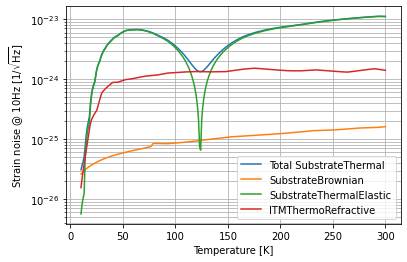

In [3]:
fig=plt.figure(figsize=(6,4))
ax=fig.add_subplot(111)
ax.semilogy(T,np.sqrt(ETSubstractThermal),label='Total SubstrateThermal')
ax.semilogy(T,np.sqrt( ETSubstrateBrownian),label='SubstrateBrownian')
ax.semilogy(T,np.sqrt(ETSubThermalElastic),label='SubstrateThermalElastic')
ax.semilogy(T,np.sqrt(ETITMThermoRefractive),label='ITMThermoRefractive')
ax.legend()
ax.grid(True, which='both')
ax.set_xlabel('Temperature [K]')
ax.set_ylabel('Strain noise @ 10Hz [$1/\sqrt{\mathrm{Hz}}$]')